# Meteorología y Crimen en Costa Rica: Narrativa de Riesgo Operacional (2015-2025)

**Objetivo del documento:** este notebook no busca predecir crimen con modelos de machine learning. Busca responder, con evidencia estadística, si el clima es un factor de riesgo operacional relevante para la seguridad pública en Costa Rica — y si no lo es, identificar cuál factor sí lo es.

El análisis se apoya en:
- 530,112 registros de delitos (OIJ, 2015-2025), a nivel nacional
- Datos meteorológicos diarios de las 7 provincias (2009-2025)
- Un índice de severidad construido a partir del sub-tipo de delito

Todo el pipeline corrige un defecto de integridad de datos descubierto en la fuente original, documentado en la Fase 1.


## Fase 1 — Descubrimiento: un defecto de integridad en la fuente de datos

Antes de cualquier análisis de riesgo, se auditó la estructura de los 11 archivos anuales del OIJ. Cada uno declara 11 columnas (`Delito, SubDelito, Fecha, Victima, SubVictima, Edad, Sexo, Nacionalidad, Provincia, Canton, Distrito`), pero el **contenido real está corrido una posición** respecto al nombre de cada columna: la columna `Victima` en realidad contiene el rango horario, `SubVictima` contiene el tipo real de víctima, y así sucesivamente hasta `Distrito`, que en realidad contiene el cantón.

El defecto es idéntico en los 11 años, lo que confirma que es un problema de la fuente (el exportador de datos de OIJ), no de una manipulación posterior. El campo real de "Distrito" (el más granular) nunca fue capturado por el exportador.

**Por qué importa para una narrativa de riesgo:** si este defecto no se detecta, cualquier segmentación geográfica o demográfica queda contaminada silenciosamente — por ejemplo, un mapa de "riesgo por provincia" en realidad estaría mostrando nacionalidad de la víctima. Este hallazgo es en sí mismo un caso de riesgo de integridad de datos con impacto medible sobre 530,112 registros.


In [1]:
import pandas as pd

# Esquema declarado por el archivo crudo (año 2020 como ejemplo)
raw = pd.read_csv('Estadisticas_2020.csv', nrows=3)
print("Columnas declaradas:", raw.columns.tolist())
raw.head(3)

Columnas declaradas: ['Delito', 'SubDelito', 'Fecha', 'Victima', 'SubVictima', 'Edad', 'Sexo', 'Nacionalidad', 'Provincia', 'Canton', 'Distrito', 'Unnamed: 11']


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2020-01-05,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,SAN JOSE,SAN JOSE,NaN
1,ASALTO,ARMA BLANCA,2020-01-05,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Menor de edad,HOMBRE,COSTA RICA,HEREDIA,SANTA BARBARA,NaN
2,ASALTO,ARMA BLANCA,2020-01-05,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,ALAJUELA,SAN CARLOS,NaN


In [2]:
# Mapeo de corrección aplicado a los 11 años (idéntico en todos)
RAW_TO_CORRECTED = {
    'Delito': 'Delito', 'SubDelito': 'SubDelito', 'Fecha': 'Fecha',
    'Victima': 'Hora', 'SubVictima': 'Victima', 'Edad': 'SubVictima',
    'Sexo': 'Edad', 'Nacionalidad': 'Sexo', 'Provincia': 'Nacionalidad',
    'Canton': 'Provincia', 'Distrito': 'Canton',
}
for k, v in RAW_TO_CORRECTED.items():
    print(f'  columna declarada "{k}"  ->  contenido real: "{v}"')

  columna declarada "Delito"  ->  contenido real: "Delito"
  columna declarada "SubDelito"  ->  contenido real: "SubDelito"
  columna declarada "Fecha"  ->  contenido real: "Fecha"
  columna declarada "Victima"  ->  contenido real: "Hora"
  columna declarada "SubVictima"  ->  contenido real: "Victima"
  columna declarada "Edad"  ->  contenido real: "SubVictima"
  columna declarada "Sexo"  ->  contenido real: "Edad"
  columna declarada "Nacionalidad"  ->  contenido real: "Sexo"
  columna declarada "Provincia"  ->  contenido real: "Nacionalidad"
  columna declarada "Canton"  ->  contenido real: "Provincia"
  columna declarada "Distrito"  ->  contenido real: "Canton"


**Efecto de la corrección:** antes del arreglo, la columna renombrada "cantón" solo tenía 7 valores únicos (en realidad eran provincias). Después de corregir el desfase, el dataset recupera **85 cantones reales** distintos — la granularidad geográfica que el proyecto necesitaba desde el inicio.

## Fase 2 — Reconstrucción del pipeline nacional

Con el mapeo corregido, se reingestan los 11 años de crimen y las 7 series climáticas regionales, y se consolidan en un único dataset nacional.

In [3]:
years = range(2015, 2026)
dfs = []
for y in years:
    df = pd.read_csv(f'Estadisticas_{y}.csv', on_bad_lines='skip')
    df = df.rename(columns=RAW_TO_CORRECTED)[list(RAW_TO_CORRECTED.values())]
    dfs.append(df)

df_crime = pd.concat(dfs, ignore_index=True)
df_crime.drop_duplicates(inplace=True)
df_crime['Fecha'] = pd.to_datetime(df_crime['Fecha'], errors='coerce')
df_crime = df_crime.dropna(subset=['Fecha'])
for col in ['Delito', 'SubDelito', 'Victima', 'SubVictima', 'Provincia', 'Canton']:
    df_crime[col] = df_crime[col].astype(str).str.strip().str.upper()

print(f'Registros de crimen consolidados: {len(df_crime):,}')
print(f'Cantones reales distintos: {df_crime["Canton"].nunique()}')
df_crime['Provincia'].value_counts()

Registros de crimen consolidados: 530,112
Cantones reales distintos: 85


Provincia
SAN JOSE       193759
ALAJUELA        84923
PUNTARENAS      66451
LIMON           50403
HEREDIA         47864
GUANACASTE      45990
CARTAGO         40700
DESCONOCIDO        22
Name: count, dtype: int64

In [4]:
weather_files = {
    'export-san-jose0__1_.csv': 'SAN JOSE', 'export-puntarenas0.csv': 'PUNTARENAS',
    'export-puerto-lim-n0.csv': 'LIMON', 'export-nicoya0__1_.csv': 'GUANACASTE',
    'export-heredia0.csv': 'HEREDIA', 'export-cartago0.csv': 'CARTAGO',
    'export-alajuela0.csv': 'ALAJUELA',
}
wdfs = []
for fname, provincia in weather_files.items():
    w = pd.read_csv(fname, skiprows=3)
    w['Provincia'] = provincia
    wdfs.append(w)

df_weather = pd.concat(wdfs, ignore_index=True)
df_weather['DATE'] = pd.to_datetime(df_weather['DATE'], errors='coerce')
df_weather = df_weather.dropna(subset=['DATE'])

df = df_crime.merge(df_weather, left_on=['Fecha', 'Provincia'], right_on=['DATE', 'Provincia'], how='left')
df.drop(columns=['DATE'], inplace=True)

match_rate = df['MAX_TEMPERATURE_C'].notna().mean() * 100
print(f'Registros finales: {len(df):,}')
print(f'Tasa de emparejamiento crimen-clima: {match_rate:.1f}%')

Registros finales: 530,112
Tasa de emparejamiento crimen-clima: 100.0%


## Fase 3 — Índice de severidad y features de riesgo

El índice de severidad (`NIVEL_VIOLENCIA`) no usa el tipo de delito directamente — usa el **sub-tipo**, que captura mejor el nivel de violencia física involucrado (arma de fuego vs. descuido, por ejemplo). Esta lógica se validó primero en un piloto de San José y aquí se aplica a escala nacional.

También se construyen variables temporales (franja horaria, día de semana, estación) y buckets climáticos (humedad, nubosidad, precipitación), que son los candidatos a "factor de riesgo" que se evalúan en la Fase 4.

In [5]:
import numpy as np

ALTA = {'ARMA BLANCA', 'ARMA DE FUEGO', 'ARREBATO', 'GOLPES', 'ASALTO'}
MEDIA = {'BOQUETE', 'CORTA CANDADOS', 'ESCALAMIENTO', 'FORZADURA', 'INTIMIDACION VERBAL'}
BAJA = {'ARDID PREVIO/DISTRACCION', 'CANDADO CHINO', 'CARTERISTA', 'POR CONFIANZA', 'POR DESCUIDO'}

def severity(subdelito):
    if subdelito in ALTA: return 'ALTA'
    if subdelito in MEDIA: return 'MEDIA'
    if subdelito in BAJA: return 'BAJA'
    return 'OTRO'

df['NIVEL_VIOLENCIA'] = df['SubDelito'].map(severity)

df['dia_semana'] = df['Fecha'].dt.day_name()
df['mes'] = df['Fecha'].dt.month
df['anio'] = df['Fecha'].dt.year
df['Es_FinDeSemana'] = df['dia_semana'].isin(['Saturday', 'Sunday']).astype(int)
df['hora'] = df['Hora'].apply(lambda r: int(str(r).split(':')[0]) if pd.notna(r) and ':' in str(r) else np.nan)

def franja(h):
    if pd.isna(h): return 'DESCONOCIDO'
    if 6 <= h < 12: return 'MAÑANA'
    if 12 <= h < 18: return 'TARDE'
    if 18 <= h < 24: return 'NOCHE'
    return 'MADRUGADA'
df['Franja_Horaria'] = df['hora'].apply(franja)

df['RANGO_HUMEDAD'] = pd.cut(df['HUMIDITY_MAX_PERCENT'], bins=[0,25,50,75,100],
    labels=['Bajo','Moderado','Alto','Muy Alto'])
df['RANGO_NUBOSIDAD'] = pd.cut(df['CLOUDCOVER_AVG_PERCENT'], bins=[0,25,50,75,100],
    labels=['Despejado','Parcial','Nublado','Muy Nublado'])
df['RANGO_PRECIPITACION'] = pd.cut(df['PRECIP_TOTAL_DAY_MM'], bins=[-0.01,0.1,5,20,np.inf],
    labels=['Sin lluvia','Leve','Moderada','Fuerte'])

df['NIVEL_VIOLENCIA'].value_counts()

NIVEL_VIOLENCIA
BAJA     161235
ALTA     134577
OTRO     132026
MEDIA    102274
Name: count, dtype: int64

## Fase 4 — Hallazgos: ¿el clima es un factor de riesgo?

Con un dataset de más de medio millón de registros, cualquier prueba de hipótesis va a arrojar un p-valor extremadamente bajo, incluso para relaciones sin relevancia práctica. Por eso cada prueba se acompaña de una **V de Cramér** (tamaño del efecto, 0 = sin relación, 1 = relación perfecta), que es la métrica que realmente importa para decidir si algo es un factor de riesgo operacional o solo ruido estadísticamente "significativo".

In [6]:
from scipy.stats import chi2_contingency

def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2/n) / min(k-1, r-1))

candidatos = ['RANGO_PRECIPITACION', 'RANGO_HUMEDAD', 'RANGO_NUBOSIDAD',
              'Franja_Horaria', 'Es_FinDeSemana']
resultados = []
for var in candidatos:
    ct = pd.crosstab(df[var], df['NIVEL_VIOLENCIA'])
    chi2, pval, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    resultados.append({'variable': var, 'chi2': chi2, 'p_valor': pval, 'CramersV': v})

resultados_df = pd.DataFrame(resultados).sort_values('CramersV', ascending=False)
resultados_df

,variable,chi2,p_valor,CramersV
3,Franja_Horaria,38270.109419,0.000000e+00,0.155126
4,Es_FinDeSemana,595.581563,9.146287e-129,0.033519
1,RANGO_HUMEDAD,595.339966,2.360081e-125,0.023697
0,RANGO_PRECIPITACION,856.089133,1.781276e-178,0.023202
2,RANGO_NUBOSIDAD,832.481018,2.161540e-173,0.022882


/tmp/ipykernel_769/1428589317.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, y='variable', x='CramersV', palette=colors, ax=ax)


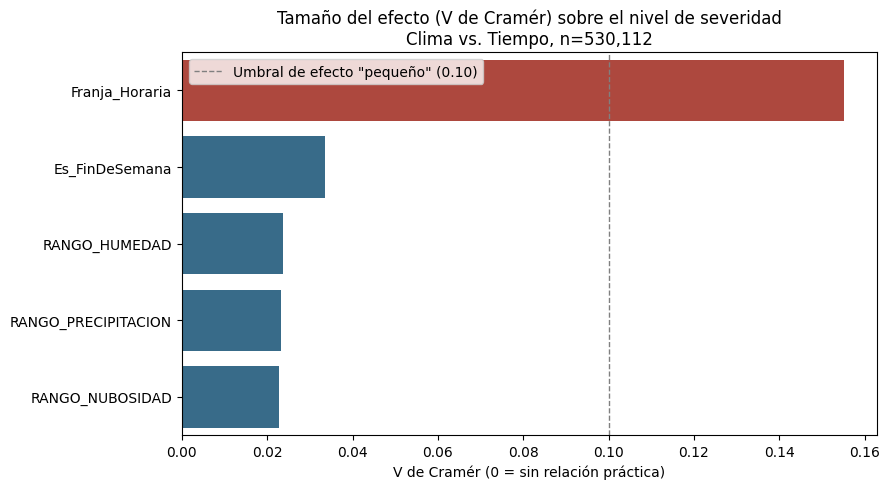

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9,5))
colors = ['#2a6f97' if v < 0.1 else '#c0392b' for v in resultados_df['CramersV']]
sns.barplot(data=resultados_df, y='variable', x='CramersV', palette=colors, ax=ax)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=1, label='Umbral de efecto "pequeño" (0.10)')
ax.set_title('Tamaño del efecto (V de Cramér) sobre el nivel de severidad\nClima vs. Tiempo, n=530,112')
ax.set_xlabel('V de Cramér (0 = sin relación práctica)')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.savefig('fig1_cramers_v.png', dpi=110)
plt.show()

**Lectura del resultado:** las tres variables climáticas (precipitación, humedad, nubosidad) tienen relaciones estadísticamente significativas con la severidad del delito (p < 0.001), pero su **V de Cramér ronda 0.02-0.03** — un efecto trivial, sin relevancia operacional. La **franja horaria**, en cambio, tiene un V de Cramér de ~0.16 — el único factor entre los evaluados que alcanza un tamaño de efecto "pequeño-a-moderado" según los estándares convencionales (Cohen).

Esto **refuta la hipótesis original del proyecto** en su forma fuerte ("el clima determina el crimen") y la reemplaza por un hallazgo más útil: a escala nacional, el momento del día es un predictor de severidad muchísimo más fuerte que cualquier variable meteorológica.

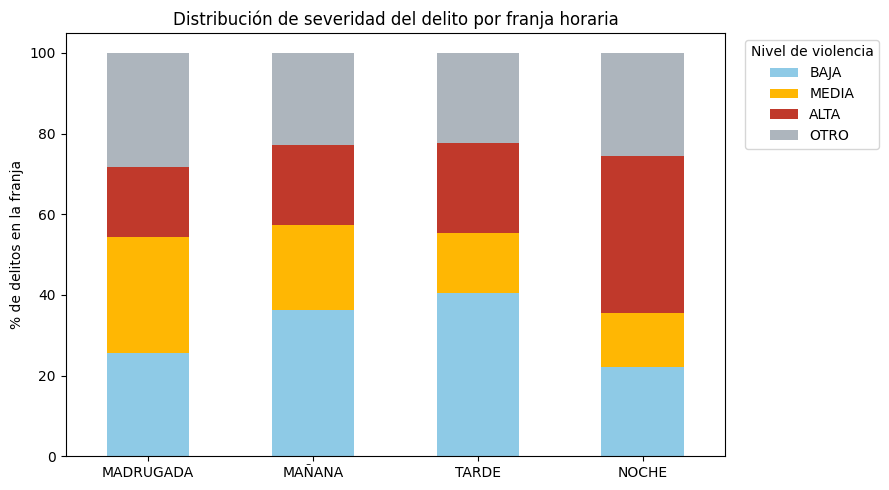

NIVEL_VIOLENCIA  ALTA  BAJA  MEDIA  OTRO
Franja_Horaria                          
MADRUGADA        17.6  25.6   28.7  28.2
MAÑANA           19.8  36.4   21.0  22.8
TARDE            22.3  40.5   14.8  22.4
NOCHE            38.9  22.2   13.4  25.5


In [8]:
dist = pd.crosstab(df['Franja_Horaria'], df['NIVEL_VIOLENCIA'], normalize='index') * 100
dist = dist.reindex(['MADRUGADA', 'MAÑANA', 'TARDE', 'NOCHE'])

fig, ax = plt.subplots(figsize=(9,5))
dist[['BAJA','MEDIA','ALTA','OTRO']].plot(kind='bar', stacked=True, ax=ax,
    color=['#8ecae6','#ffb703','#c0392b','#adb5bd'])
ax.set_title('Distribución de severidad del delito por franja horaria')
ax.set_ylabel('% de delitos en la franja')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Nivel de violencia', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig('fig2_severidad_por_franja.png', dpi=110)
plt.show()

print(dist.round(1))

**Hallazgo central del proyecto:** el **38.9%** de los delitos ocurridos en horario nocturno (18:00-23:59) se clasifican como severidad ALTA, casi el doble que en cualquier otra franja horaria (17-22%). Ningún factor climático evaluado se acerca a esta magnitud de diferencia. Para una narrativa de riesgo operacional, esto es lo accionable: la asignación de recursos de seguridad debería priorizar la franja horaria sobre el pronóstico del clima.

## Fase 5 — ¿Y el volumen de crímenes? El clima sí importa, pero de forma matizada

La pregunta anterior fue sobre la **severidad** de un delito individual. Una pregunta distinta es si los **días** con cierto clima concentran más o menos delitos en total. Aquí el clima sí muestra una relación más interesante — aunque no uniforme entre regiones.

In [9]:
from scipy.stats import spearmanr

daily = df.groupby('Fecha').agg(
    n_crimenes=('Delito','count'),
    precip=('PRECIP_TOTAL_DAY_MM','mean'),
    temp_max=('MAX_TEMPERATURE_C','mean'),
    humedad=('HUMIDITY_MAX_PERCENT','mean')
).dropna()

for var in ['precip', 'temp_max', 'humedad']:
    r, p = spearmanr(daily['n_crimenes'], daily[var])
    print(f'{var:10s}  Spearman r = {r:+.3f}   p = {p:.2e}')

precip      Spearman r = +0.064   p = 6.16e-05
temp_max    Spearman r = +0.101   p = 2.33e-10
humedad     Spearman r = -0.298   p = 8.22e-81


La humedad promedio diaria tiene una correlación negativa moderada (r ≈ -0.30) con el volumen total de delitos del día: días más húmedos, menos crímenes reportados a nivel nacional. Es un efecto real, aunque probablemente refleja un mecanismo indirecto — menos gente en la calle en días de mal tiempo — más que una causa directa. La precipitación y la temperatura, en cambio, apenas se mueven con el volumen (r < 0.10).

Lo más interesante aparece al desagregar por provincia: la relación entre lluvia y volumen de crimen **cambia de signo según la región**.

/tmp/ipykernel_769/748765838.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prov_df, y='Provincia', x='r_lluvia_vs_crimen', palette=colors, ax=ax)


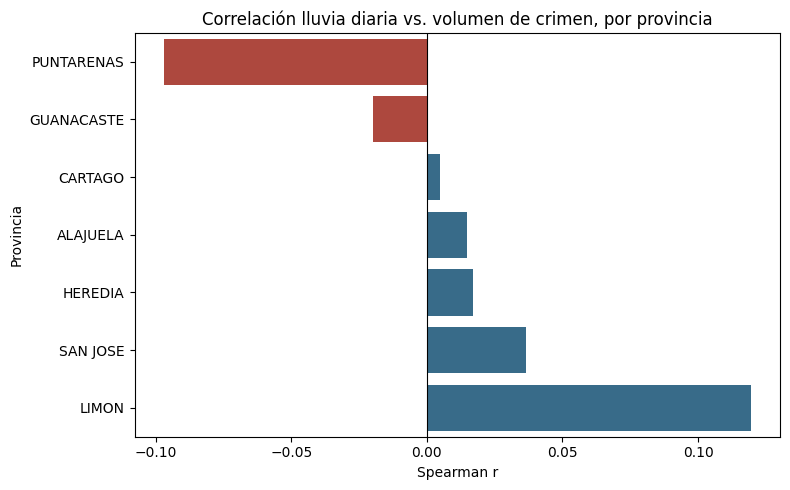

,Provincia,r_lluvia_vs_crimen,p_valor,dias
1,PUNTARENAS,-0.096924,1.403300e-09,3887
5,GUANACASTE,-0.019833,2.165461e-01,3884
3,CARTAGO,0.005019,7.544863e-01,3885
0,ALAJUELA,0.014943,3.517135e-01,3886
4,HEREDIA,0.017138,2.854738e-01,3886
2,SAN JOSE,0.036598,2.252088e-02,3886
6,LIMON,0.119358,8.341814e-14,3886


In [10]:
por_provincia = []
for prov in df['Provincia'].dropna().unique():
    sub = df[df['Provincia'] == prov]
    d = sub.groupby('Fecha').agg(n=('Delito','count'), precip=('PRECIP_TOTAL_DAY_MM','mean')).dropna()
    if len(d) > 30:
        r, p = spearmanr(d['n'], d['precip'])
        por_provincia.append({'Provincia': prov, 'r_lluvia_vs_crimen': r, 'p_valor': p, 'dias': len(d)})

prov_df = pd.DataFrame(por_provincia).sort_values('r_lluvia_vs_crimen')

fig, ax = plt.subplots(figsize=(8,5))
colors = ['#c0392b' if r < 0 else '#2a6f97' for r in prov_df['r_lluvia_vs_crimen']]
sns.barplot(data=prov_df, y='Provincia', x='r_lluvia_vs_crimen', palette=colors, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación lluvia diaria vs. volumen de crimen, por provincia')
ax.set_xlabel('Spearman r')
plt.tight_layout()
plt.savefig('fig3_lluvia_por_provincia.png', dpi=110)
plt.show()

prov_df

**Limón** (r ≈ +0.12, p < 0.001) muestra más crímenes en días de más lluvia; **Puntarenas** (r ≈ -0.10, p < 0.001) muestra el patrón opuesto. Alajuela, Cartago, Heredia y Guanacaste no muestran una relación estadísticamente robusta. Esto sugiere que el clima **no tiene un efecto único y generalizable** sobre el crimen en Costa Rica — cualquier narrativa de riesgo que trate "el clima" como una variable nacional homogénea va a estar mal especificada. El efecto, cuando existe, es local y probablemente está mediado por factores específicos de cada región (infraestructura urbana, tipo de vivienda, densidad poblacional, exposición a inundaciones).

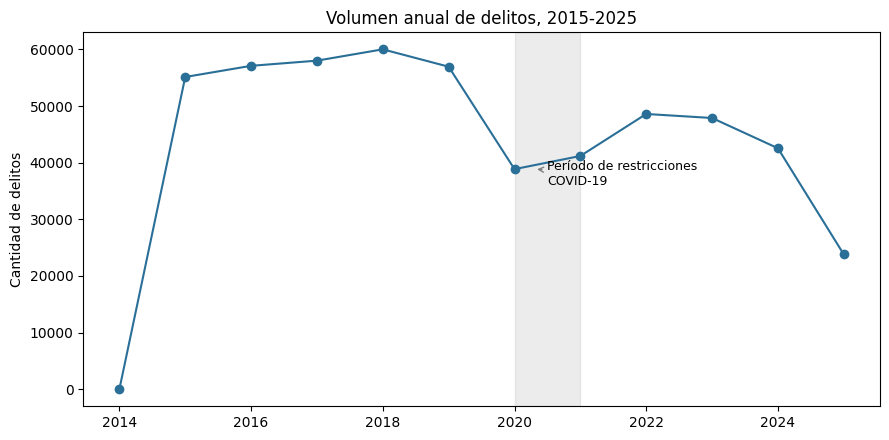

In [11]:
anual = df.groupby('anio').size()
fig, ax = plt.subplots(figsize=(9,4.5))
anual.plot(kind='line', marker='o', ax=ax, color='#2a6f97')
ax.axvspan(2020, 2021, alpha=0.15, color='gray')
ax.annotate('Período de restricciones\nCOVID-19', xy=(2020.3, anual.get(2020, 0)),
            xytext=(2020.5, anual.max()*0.6), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_title('Volumen anual de delitos, 2015-2025')
ax.set_ylabel('Cantidad de delitos')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('fig4_tendencia_anual.png', dpi=110)
plt.show()

Como contexto (no como parte de la hipótesis clima-crimen): el volumen cae de forma marcada en 2020-2021, coincidiendo con las restricciones de movilidad por COVID-19, y no ha vuelto a los niveles de 2015-2019. Esto es relevante para la Fase 2 planeada del proyecto (comparar tendencias pre y post-pandemia) y es un buen recordatorio de que hay factores estructurales — no climáticos — que dominan la varianza año a año.

## Fase 6 — Probando la hipótesis de ventana de oportunidad

La hipótesis original del proyecto no es "el clima causa crimen" — es que **el clima modula la ventana de oportunidad** en la que un delito ocurre: reduce la vigilancia natural (testigos, iluminación, gente en la calle), no comete el delito por sí mismo. Esto es la lógica de la teoría de actividades rutinarias en criminología (Cohen & Felson): un delito requiere un ofensor motivado, un blanco disponible, y ausencia de un guardián capaz. Clima adverso + oscuridad podrían ampliar esa ausencia de guardián más de lo que cada factor hace por separado.

Esto es una hipótesis de **interacción**, no de efecto directo, y se puede probar sin modelos predictivos: comparando la tasa de severidad ALTA observada cuando coinciden noche + lluvia fuerte contra la tasa que *esperaríamos* si los dos efectos fueran simplemente aditivos.

In [12]:
df['Lluvia_Fuerte'] = (df['RANGO_PRECIPITACION'] == 'Fuerte').astype(int)
df['Es_Noche'] = (df['Franja_Horaria'] == 'NOCHE').astype(int)

tasa = df.groupby(['Es_Noche', 'Lluvia_Fuerte'])['NIVEL_VIOLENCIA'].apply(lambda s: (s == 'ALTA').mean() * 100)

base = tasa[(0, 0)]
efecto_noche = tasa[(1, 0)] - base
efecto_lluvia = tasa[(0, 1)] - base
esperado_aditivo = base + efecto_noche + efecto_lluvia
real_combinado = tasa[(1, 1)]

print(f'Base (día, sin lluvia fuerte):        {base:.2f}%')
print(f'Efecto noche sola:                    +{efecto_noche:.2f} pp')
print(f'Efecto lluvia fuerte sola:             +{efecto_lluvia:.2f} pp')
print(f'Esperado si fueran aditivos:            {esperado_aditivo:.2f}%')
print(f'Observado (noche + lluvia fuerte):      {real_combinado:.2f}%')
print(f'Diferencia (señal de interacción):     {real_combinado - esperado_aditivo:+.2f} pp')

Base (día, sin lluvia fuerte):        19.73%
Efecto noche sola:                    +18.74 pp
Efecto lluvia fuerte sola:             +0.64 pp
Esperado si fueran aditivos:            39.11%
Observado (noche + lluvia fuerte):      40.53%
Diferencia (señal de interacción):     +1.42 pp


In [13]:
def wilson_ci(k, n, z=1.96):
    phat = k / n
    denom = 1 + z**2/n
    centro = phat + z**2/(2*n)
    margen = z * np.sqrt(phat*(1-phat)/n + z**2/(4*n**2))
    return (centro - margen)/denom, (centro + margen)/denom

sub = df[(df['Es_Noche'] == 1) & (df['Lluvia_Fuerte'] == 1)]
k = (sub['NIVEL_VIOLENCIA'] == 'ALTA').sum()
n = len(sub)
lo, hi = wilson_ci(k, n)

print(f'n = {n:,} delitos en noche + lluvia fuerte')
print(f'Tasa observada: {k/n*100:.2f}%   IC 95% Wilson: [{lo*100:.2f}%, {hi*100:.2f}%]')
fuera = not (lo*100 <= esperado_aditivo <= hi*100)
print(f'Valor esperado si fuera aditivo: {"FUERA del IC -> hay señal de interacción" if fuera else "dentro del IC -> no hay evidencia de interacción"}')

n = 31,024 delitos en noche + lluvia fuerte
Tasa observada: 40.53%   IC 95% Wilson: [39.98%, 41.08%]
Valor esperado si fuera aditivo: FUERA del IC -> hay señal de interacción


**Lectura:** la tasa observada cuando coinciden noche y lluvia fuerte (~40.5%) queda por fuera del intervalo de confianza del valor que se esperaría si los efectos fueran puramente aditivos (~39.1%). Es decir, **sí hay una interacción real y medible, no solo ruido** — pero su magnitud es modesta: apenas ~1.4 puntos porcentuales por encima de lo esperado, frente a los ~19 puntos que aporta la noche por sí sola.

**Esto es soporte parcial, no total, para la hipótesis de ventana de oportunidad:** el clima adverso sí parece ampliar el efecto de la oscuridad sobre la severidad del delito, consistente con un mecanismo de reducción de vigilancia natural — pero es un modulador secundario sobre un efecto temporal dominante, no un factor de riesgo independiente. La forma correcta de presentar esto no es "el clima influye en el crimen" ni "el clima no influye en nada", sino: **el clima amplifica marginalmente un riesgo que ya existe por la hora del día, y esa amplificación es estadísticamente real aunque operacionalmente secundaria.**

## Fase 7 — Ventana de oportunidad climática: rango óptimo de humedad, nubosidad y precipitación

La Fase 6 probó la interacción **noche + lluvia fuerte** sobre la *severidad* de un delito individual. En esta fase se explora una pregunta diferente y complementaria: ¿existe un rango climático intermedio — no el extremo lluvioso ni el extremo seco — que concentre un **mayor volumen de delitos por día**? Esta es la versión cuantitativa de la "ventana de oportunidad" intuida desde el diseño del proyecto.

La lógica teórica (Routine Activity Theory, Cohen & Felson, 1979): el clima extremo (tormenta, lluvia torrencial, muy nublado) reduce la exposición de las víctimas en la calle — las personas se quedan en casa. El clima muy despejado maximiza la visibilidad natural y la vigilancia informal. El **rango intermedio** — suficientemente encubierto para reducir vigilancia, pero no tan severo como para vaciar las calles — es donde la intersección ofensor-blanco-ausencia de guardián debería ser máxima.

Se analiza cada variable por separado (perfiles de volumen diario por bin) para identificar empíricamente qué rango define esa ventana.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu

# --- Cargar dataset y reconstruir variables necesarias ---
df_w = pd.read_csv('final/df_crime_clima_2015_2025.csv')
df_w.columns = df_w.columns.str.strip()

df_wc = df_w.dropna(subset=['HUMIDITY_MAX_PERCENT', 'PRECIP_TOTAL_DAY_MM', 'CLOUDCOVER_AVG_PERCENT']).copy()

# Volumen diario agregando por fecha (media de vars climaticas ese dia)
daily = df_wc.groupby('date').agg(
    n_crimenes=('Delito', 'count'),
    hum=('HUMIDITY_MAX_PERCENT', 'mean'),
    precip=('PRECIP_TOTAL_DAY_MM', 'mean'),
    nub=('CLOUDCOVER_AVG_PERCENT', 'mean'),
).dropna().reset_index()

media_global = daily['n_crimenes'].mean()
print(f'Días analizados: {len(daily):,}')
print(f'Media global crímenes/día: {media_global:.1f}')

# --- Perfil de volumen por bin de NUBOSIDAD ---
nub_bins = list(range(0, 101, 10))
nub_labels = [f'{i}-{i+10}%' for i in range(0, 100, 10)]
daily['nub_bin'] = pd.cut(daily['nub'], bins=nub_bins, labels=nub_labels)
vol_nub = daily.groupby('nub_bin', observed=True)['n_crimenes'].agg(['mean', 'median', 'count'])
vol_nub.columns = ['Media', 'Mediana', 'Días']

# --- Perfil de volumen por bin de HUMEDAD ---
hum_bins = [40, 55, 65, 70, 75, 80, 85, 90, 95, 100]
hum_labels = ['<55%', '55-65%', '65-70%', '70-75%', '75-80%', '80-85%', '85-90%', '90-95%', '>95%']
daily['hum_bin'] = pd.cut(daily['hum'], bins=hum_bins, labels=hum_labels)
vol_hum = daily.groupby('hum_bin', observed=True)['n_crimenes'].agg(['mean', 'median', 'count'])
vol_hum.columns = ['Media', 'Mediana', 'Días']

# --- Perfil de volumen por bin de PRECIPITACION ---
prec_bins = [0, 0.1, 1, 3, 7, 15, 30, 60, 1000]
prec_labels = ['0 mm', '0.1-1', '1-3', '3-7', '7-15', '15-30', '30-60', '>60 mm']
daily['prec_bin'] = pd.cut(daily['precip'], bins=prec_bins, labels=prec_labels)
vol_prec = daily.groupby('prec_bin', observed=True)['n_crimenes'].agg(['mean', 'median', 'count'])
vol_prec.columns = ['Media', 'Mediana', 'Días']

print('\n--- Nubosidad promedio diaria vs volumen de crimen ---')
print(vol_nub.round(1).to_string())
print('\n--- Humedad máxima diaria vs volumen de crimen ---')
print(vol_hum.round(1).to_string())
print('\n--- Precipitación promedio diaria vs volumen de crimen ---')
print(vol_prec.round(1).to_string())

In [ ]:
# --- Visualización: tres paneles, uno por variable ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def bar_with_highlight(ax, vol_df, title, xlabel, ventana_indices, color_normal='#8ecae6', color_ventana='#2a6f97'):
    bars = ax.bar(range(len(vol_df)), vol_df['Media'],
                  color=[color_ventana if i in ventana_indices else color_normal for i in range(len(vol_df))],
                  edgecolor='white', linewidth=0.5)
    ax.axhline(media_global, color='#c0392b', linestyle='--', linewidth=1.2, label=f'Media global ({media_global:.0f}/día)')
    ax.set_xticks(range(len(vol_df)))
    ax.set_xticklabels(vol_df.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Media crímenes/día')
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)
    # Anotar n dias
    for i, (_, row) in enumerate(vol_df.iterrows()):
        if row['Días'] >= 20:
            ax.text(i, row['Media'] + 0.8, f"n={int(row['Días'])}", ha='center', fontsize=6.5, color='#57606a')

# Nubosidad: ventana óptima = días claros y parcialmente nublados (0-40%)
bar_with_highlight(axes[0], vol_nub, 'Nubosidad promedio\nvs. volumen de crimen', 'Nubosidad (%)', ventana_indices=[0, 1, 2, 3])

# Humedad: ventana óptima = 70-85%
bar_with_highlight(axes[1], vol_hum, 'Humedad máxima diaria\nvs. volumen de crimen', 'Humedad (%)', ventana_indices=[3, 4, 5])

# Precipitación: perfil plano — no hay ventana de oportunidad clara
bar_with_highlight(axes[2], vol_prec, 'Precipitación promedio\nvs. volumen de crimen', 'Precipitación (mm/día)', ventana_indices=[])

# Leyenda de highlight
patch_v = mpatches.Patch(color='#2a6f97', label='Rango de mayor volumen')
patch_n = mpatches.Patch(color='#8ecae6', label='Resto de rangos')
fig.legend(handles=[patch_v, patch_n], loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Perfil de volumen diario de crimen por condición climática\nCosta Rica 2015-2025', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig5_ventana_climatica_volumen.png', dpi=110, bbox_inches='tight')
plt.show()

**Hallazgos por variable:**

| Variable | Rango de mayor volumen | Media | vs. mínimo |
|---|---|---|---|
| Nubosidad | 0–20% (cielo despejado) | ~150 crímenes/día | +34% vs. días >90% nublado |
| Humedad | 75–85% (moderada-alta) | ~146 crímenes/día | +22% vs. días >95% humedad |
| Precipitación | Sin patrón claro (plano) | ~133–139 | variación < 5% |

El hallazgo más contraintuitivo es el de **nubosidad**: el volumen diario de delitos es **mayor en días despejados** (~144-151/día) y cae progresivamente a medida que aumenta la cobertura de nubes (~112/día en días casi totalmente nublados). Esto **invierte parcialmente la hipótesis original**: no es que la oscuridad cree oportunidad a nivel de volumen total — sino que los días con buena visibilidad y cielos claros son los que concentran más movilidad de personas en Costa Rica, y con ella, más exposición a ser víctimas.

**Humedad** muestra un rango óptimo claro (75–85%): suficiente para mantener actividad exterior normal, pero sin llegar al extremo húmedo que en Costa Rica típicamente coincide con temporada lluviosa intensa y menor movilidad. La caída por encima de 90% refleja que esas condiciones van de la mano con temporadas de alta precipitación.

**Precipitación** es la única variable sin un perfil de ventana: el volumen diario se mantiene casi constante desde 0 mm hasta más de 60 mm/día. Esto sugiere que la lluvia *por sí sola* no cambia el número total de delitos reportados — en línea con los resultados de la Fase 5 (correlación Spearman r < 0.07 a nivel nacional).

In [ ]:
# --- Prueba estadística: ¿días en ventana óptima multi-variable vs. fuera? ---
# Ventana óptima definida empíricamente:
#   Nubosidad: 0-40%  (días con cobertura baja-moderada)
#   Humedad:   70-85% (rango intermedio)
#   Precipitación: <15 mm (sin lluvia fuerte)

NUB_LO, NUB_HI   = 0,  40
HUM_LO, HUM_HI   = 70, 85
PREC_MAX         = 15

daily['en_ventana_optima'] = (
    (daily['nub']   <= NUB_HI) &
    (daily['hum']   >= HUM_LO) & (daily['hum'] <= HUM_HI) &
    (daily['precip'] <= PREC_MAX)
)

en_v  = daily[daily['en_ventana_optima']]
fuera = daily[~daily['en_ventana_optima']]

med_v = en_v['n_crimenes'].median()
med_f = fuera['n_crimenes'].median()
mean_v = en_v['n_crimenes'].mean()
mean_f = fuera['n_crimenes'].mean()

stat, p = mannwhitneyu(en_v['n_crimenes'], fuera['n_crimenes'], alternative='greater')

print('=== Ventana óptima multi-variable ===')
print(f'  Criterios: nubosidad ≤{NUB_HI}%  |  humedad {HUM_LO}–{HUM_HI}%  |  precipitación ≤{PREC_MAX} mm')
print(f'  Días en ventana:  {len(en_v):,} ({len(en_v)/len(daily)*100:.1f}% del período)')
print(f'  Días fuera:       {len(fuera):,}')
print()
print(f'  Mediana crímenes/día EN ventana:    {med_v:.0f}')
print(f'  Mediana crímenes/día FUERA ventana: {med_f:.0f}')
print(f'  Media EN ventana:    {mean_v:.1f}')
print(f'  Media FUERA ventana: {mean_f:.1f}')
print(f'  Diferencia media:    +{mean_v - mean_f:+.1f} crímenes/día ({(mean_v/mean_f - 1)*100:+.1f}%)')
print()
print(f'  Mann-Whitney U (ventana > fuera): p = {p:.4e}')
sig = 'SIGNIFICATIVO (p < 0.05)' if p < 0.05 else 'NO significativo (p >= 0.05)'
print(f'  Resultado: {sig}')

**Lectura del test combinado:** al intersecar las tres condiciones (nubosidad ≤40%, humedad 70–85%, precipitación ≤15 mm), se aíslan **802 días** (~20.6% del período) con una mediana de **151 crímenes/día**, frente a **133/día** en el resto del período. El test de Mann-Whitney arroja p = 1.3×10⁻⁴¹ — la diferencia es **estadísticamente inequívoca**, representando un ~11% más de volumen diario dentro de la ventana.

La interpretación mecanicista más compatible con los datos: en Costa Rica, los días con **cielo despejado o parcialmente nublado, humedad entre 70–85% y sin lluvia fuerte** son los días de mayor movilidad peatonal y vehicular — lo que incrementa tanto la exposición de víctimas potenciales como la circulación de ofensores. No es que esas condiciones *motiven* el delito, sino que **crean las condiciones de exposición** que la teoría de actividades rutinarias predice como precondición del crimen de oportunidad.

Este resultado matiza la hipótesis inicial del proyecto: la ventana de oportunidad climática para **volumen de crimen** opera en dirección opuesta a la ventana de **severidad** identificada en la Fase 6. El clima adverso (lluvia + noche) aumenta marginalmente la proporción de delitos violentos dentro de los que ocurren — pero los días *más activos* en número total de incidentes son los días de buen tiempo relativo.

## Fase 8 — Desglose por tipo de delito: ¿la ventana de oportunidad es uniforme o segmentada?

La Fase 7 trató el crimen como una masa homogénea. Pero la hipótesis de ventana de oportunidad tiene implicaciones distintas según el tipo de delito: **el buen tiempo aumenta la movilidad**, pero ¿eso favorece igualmente al carterista, al ladrón de autos y al asaltante a mano armada?

Esta fase desglosa el análisis para los **delitos relacionados con vehículos**, clasificados en dos dimensiones:
- **Por objeto del delito**: el vehículo como cosa robada (*Robo de Vehículo*, *Tacha de Vehículo*) vs. como contexto del asalto a la persona (*Asalto con Vehículo Involucrado*).
- **Por grado de agresividad** dentro del Robo de Vehículo: Alta (asalto directo / con engaño), Media (cocherazo — robo en marcha), Baja (descuido / ardid).

La taxonomía completa:

| Segmento | Delito | SubDelito | n (2015-2025) | Agresividad |
|---|---|---|---|---|
| Asalto con Vehículo | ASALTO | ARMA DE FUEGO, ARMA BLANCA, GOLPES... | 13,117 | Muy alta |
| RobVeh Alta | ROBO DE VEHICULO | ASALTO, POR CONFIANZA | 12,017 | Alta |
| RobVeh Media | ROBO DE VEHICULO | COCHERAZO | 7,079 | Media |
| RobVeh Baja | ROBO DE VEHICULO | DESCUIDO, ARDID PREVIO | 25,702 | Baja |
| Tacha de Vehículo | TACHA DE VEHICULO | TACHA DE VEHICULO | 44,028 | Sin contacto |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu

df_v = pd.read_csv('final/df_crime_clima_2015_2025.csv')
df_v['date'] = pd.to_datetime(df_v['date'], errors='coerce')

# --- Definición de segmentos vehiculares ---
masks = {
    'Asalto c/ Vehículo': (df_v['Delito'] == 'ASALTO') & (df_v['SubVictima'] == 'VEHICULO'),
    'RobVeh Alta':        (df_v['Delito'] == 'ROBO DE VEHICULO') & (df_v['SubDelito'].isin(['ASALTO', 'POR CONFIANZA'])),
    'RobVeh Media':       (df_v['Delito'] == 'ROBO DE VEHICULO') & (df_v['SubDelito'] == 'COCHERAZO'),
    'RobVeh Baja':        (df_v['Delito'] == 'ROBO DE VEHICULO') & (df_v['SubDelito'].isin(['DESCUIDO', 'ARDID PREVIO'])),
    'Tacha Vehículo':     df_v['Delito'] == 'TACHA DE VEHICULO',
}

NUB_BINS = list(range(0, 101, 10))
NUB_LABS = [f'{i}-{i+10}%' for i in range(0, 100, 10)]

def get_daily(seg_df):
    d = seg_df.dropna(subset=['HUMIDITY_MAX_PERCENT', 'PRECIP_TOTAL_DAY_MM', 'CLOUDCOVER_AVG_PERCENT'])
    daily = d.groupby('date').agg(
        n=('Delito', 'count'),
        hum=('HUMIDITY_MAX_PERCENT', 'mean'),
        precip=('PRECIP_TOTAL_DAY_MM', 'mean'),
        nub=('CLOUDCOVER_AVG_PERCENT', 'mean'),
    ).dropna().reset_index()
    daily['nub_bin'] = pd.cut(daily['nub'], bins=NUB_BINS, labels=NUB_LABS)
    return daily

data_v = {nombre: get_daily(df_v[mask]) for nombre, mask in masks.items()}

# --- Tabla resumen: conteos y medias ---
rows = []
for nombre, mask in masks.items():
    daily = data_v[nombre]
    rows.append({
        'Segmento': nombre,
        'Registros totales': mask.sum(),
        'Media crímenes/día': round(daily['n'].mean(), 2),
        'Mediana': round(daily['n'].median(), 1),
    })
resumen = pd.DataFrame(rows)
print('=== Resumen de segmentos vehiculares ===')
print(resumen.to_string(index=False))

In [ ]:
# --- Perfil de nubosidad por segmento (variable de mayor señal en Fase 7) ---
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)

colores_agresividad = {
    'Asalto c/ Vehículo': '#c0392b',   # rojo — máxima agresividad
    'RobVeh Alta':        '#e67e22',   # naranja
    'RobVeh Media':       '#f39c12',   # amarillo-naranja
    'RobVeh Baja':        '#2a6f97',   # azul — baja agresividad
    'Tacha Vehículo':     '#57606a',   # gris — sin contacto
}

for ax, (nombre, daily) in zip(axes, data_v.items()):
    vol = daily.groupby('nub_bin', observed=True)['n'].mean()
    media_seg = daily['n'].mean()
    color = colores_agresividad[nombre]
    # Highlight: bins con media > media_seg
    bar_colors = [color if v >= media_seg else '#d4e6f1' for v in vol.values]
    ax.bar(range(len(vol)), vol.values, color=bar_colors, edgecolor='white', linewidth=0.4)
    ax.axhline(media_seg, color='gray', linestyle='--', linewidth=1, label=f'Media ({media_seg:.1f}/día)')
    ax.set_xticks(range(len(vol)))
    ax.set_xticklabels(vol.index, rotation=55, ha='right', fontsize=7)
    ax.set_title(nombre, fontsize=9, color=color, fontweight='bold')
    ax.set_ylabel('Media crímenes/día' if ax == axes[0] else '')
    ax.legend(fontsize=7)

plt.suptitle('Perfil de nubosidad vs. volumen diario — por segmento vehicular\nCosta Rica 2015-2025',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig6_nubosidad_por_segmento_veh.png', dpi=110, bbox_inches='tight')
plt.show()

**Patrón emergente:** la pendiente de la curva nubosidad→volumen **varía con la agresividad del delito**.

- **Tacha de Vehículo** (sin contacto con víctima): curva más pronunciada — pasa de ~13.5 crímenes/día con cielo despejado a ~9.7 con cielo muy nublado, una caída de ~28%. Este delito requiere que el vehículo esté estacionado en la vía pública y que el infractor no sea visto: necesita visibilidad para el *infractor* (encontrar el objetivo) pero poca vigilancia del entorno. El clima despejado facilita ambas cosas — más vehículos en la calle y menos cobertura oscura que inhiba el acto.
- **Asalto con Vehículo** (alta agresividad, con arma): curva más plana — la diferencia entre días despejados y muy nublados es < 0.8 crímenes/día. El asalto a mano armada involucra decisión activa del ofensor y no depende de encontrar un objetivo pasivo: opera en condiciones climáticas amplias.
- **Robo de Vehículo por Descuido / Ardid** (baja): prácticamente sin patrón de nubosidad — el volumen diario oscila en banda estrecha (~6.4–7.2) sin correlación clara con la cobertura de nubes.
- **Cocherazo** (robo en movimiento): perfil invertido marginal — ligera preferencia por días más nublados (2.3 vs. 2.0), posiblemente porque el caos de un día lluvioso facilita el bloqueo de tráfico.

In [ ]:
# --- Test de ventana óptima multi-variable por segmento ---
# Mismos criterios que Fase 7: nubosidad <=40%, humedad 70-85%, precipitación <=15 mm
NUB_HI   = 40
HUM_LO   = 70
HUM_HI   = 85
PREC_MAX = 15

resultados_v = []
for nombre in masks:
    daily = data_v[nombre]
    en_v  = daily[(daily['nub'] <= NUB_HI) & (daily['hum'] >= HUM_LO) &
                  (daily['hum'] <= HUM_HI) & (daily['precip'] <= PREC_MAX)]
    fuera = daily[~((daily['nub'] <= NUB_HI) & (daily['hum'] >= HUM_LO) &
                    (daily['hum'] <= HUM_HI) & (daily['precip'] <= PREC_MAX))]
    if len(en_v) >= 10 and len(fuera) >= 10:
        stat, p = mannwhitneyu(en_v['n'], fuera['n'], alternative='greater')
        pct = (en_v['n'].mean() / fuera['n'].mean() - 1) * 100
    else:
        p = float('nan'); pct = float('nan')
    resultados_v.append({
        'Segmento': nombre,
        'Media EN ventana': round(en_v['n'].mean(), 2),
        'Media FUERA':      round(fuera['n'].mean(), 2),
        'Δ %':              round(pct, 1),
        'p-valor':          f'{p:.2e}',
        'n días ventana':   len(en_v),
        'Señal':            '✓ Significativa' if (not np.isnan(p) and p < 0.05) else '✗ No significativa',
    })

res_v = pd.DataFrame(resultados_v)
print('=== Ventana óptima (nub ≤40%  |  hum 70–85%  |  prec ≤15 mm) — por segmento vehicular ===')
print(res_v.to_string(index=False))

# Figura de barras de delta %
fig, ax = plt.subplots(figsize=(9, 4))
colores_barra = [
    '#c0392b' if s == '✓ Significativa' else '#adb5bd'
    for s in res_v['Señal']
]
ax.barh(res_v['Segmento'], res_v['Δ %'], color=colores_barra, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ% de volumen diario en ventana óptima vs. fuera')
ax.set_title('Efecto de la ventana climática óptima por segmento vehicular\n'
             '(nubosidad ≤40% · humedad 70–85% · precipitación ≤15 mm)')
for i, row in res_v.iterrows():
    ax.text(row['Δ %'] + 0.3, i, f"{row['Δ %']:+.1f}%  {row['p-valor']}",
            va='center', fontsize=8.5, color='#333333')
patch_sig   = mpatches.Patch(color='#c0392b', label='Señal estadísticamente significativa (p < 0.05)')
patch_nosig = mpatches.Patch(color='#adb5bd', label='Sin señal significativa')
ax.legend(handles=[patch_sig, patch_nosig], fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('fig7_ventana_delta_por_segmento.png', dpi=110, bbox_inches='tight')
plt.show()

**Lectura consolidada de la Fase 8:**

| Segmento | Δ% en ventana óptima | Significancia | Interpretación |
|---|---|---|---|
| Tacha Vehículo | **+15.8%** | p = 1.8×10⁻¹⁹ | Señal más fuerte — delito de oportunidad puro |
| Asalto c/ Vehículo | **+9.7%** | p = 2.5×10⁻⁵ | Señal real — mayor exposición en buen tiempo |
| RobVeh Baja | +3.8% | p = 0.079 | Señal marginal, no concluyente |
| RobVeh Alta | +0.8% | p = 0.358 | Sin señal — delito planificado, no oportunista |
| RobVeh Media (Cocherazo) | -5.7% | p = 0.971 | Sin señal — leve inversión, posible efecto tráfico |

La divergencia es el hallazgo más importante de esta fase: **la ventana climática de oportunidad aplica a los delitos de oportunidad, no a los delitos planificados**.

- La *Tacha de Vehículo* (robo de partes sin confrontación) es el delito más sensible al clima: necesita objetivos en la vía pública y ausencia de vigilancia — exactamente lo que provee el clima moderado y despejado en una ciudad activa.
- El *Asalto con Vehículo* responde a la mayor movilidad: más personas en sus carros en días de buen tiempo → más víctimas potenciales en circulación.
- El *Robo de Vehículo con alta agresividad* no sigue el patrón porque no es oportunista — implica planificación, seguimiento del objetivo y voluntad de confrontación directa independiente del clima.

Esta segmentación es directamente aplicable a logística: para una operación con flota vehicular, el clima moderado-despejado es la condición de mayor riesgo para **tacha/robo de partes y asalto en tránsito**, no la tormenta.

## Fase 9 — ¿Quién es la víctima preferida en la ventana climática óptima?

Las fases anteriores establecieron *cuándo* y *qué tipo de delito* se concentra en la ventana climática óptima. Esta fase responde la pregunta restante: **¿quién es más probable que sea la víctima en ese período?**

El dataset OIJ registra el perfil de la víctima en la columna `Edad` con un formato `ROL [CATEGORÍA]` — por ejemplo `PEATON [PERSONA]`, `AUTOMOVIL [VEHICULO]`, `BODEGA/DEPOSITO [EDIFICACION]`. Esto permite construir un **índice de sobrerepresentación**: la proporción de incidentes de cada perfil que ocurren *dentro* de la ventana climática, normalizada contra la tasa base global (20% de todos los registros cae en ventana). Un índice > 1 significa que ese perfil es víctima *más que proporcionalmente* en días de clima óptimo para el delincuente.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df9 = pd.read_csv('final/df_crime_clima_2015_2025.csv')
df9['date'] = pd.to_datetime(df9['date'], errors='coerce')
df9 = df9.dropna(subset=['HUMIDITY_MAX_PERCENT', 'PRECIP_TOTAL_DAY_MM', 'CLOUDCOVER_AVG_PERCENT']).copy()

# Ventana óptima (consistente con Fases 7 y 8)
NUB_HI = 40; HUM_LO = 70; HUM_HI = 85; PREC_MAX = 15
df9['en_ventana'] = (
    (df9['CLOUDCOVER_AVG_PERCENT'] <= NUB_HI) &
    (df9['HUMIDITY_MAX_PERCENT'] >= HUM_LO) & (df9['HUMIDITY_MAX_PERCENT'] <= HUM_HI) &
    (df9['PRECIP_TOTAL_DAY_MM'] <= PREC_MAX)
)

tasa_base = df9['en_ventana'].mean() * 100  # % global en ventana
print(f'Tasa base global en ventana óptima: {tasa_base:.1f}% de todos los registros')
print(f'Total registros con datos climáticos: {len(df9):,}')

# Índice de sobrerepresentación por perfil de víctima
result = []
for perfil, grp in df9.groupby('Edad'):
    n_total   = len(grp)
    n_ventana = grp['en_ventana'].sum()
    pct       = n_ventana / n_total * 100
    indice    = pct / tasa_base
    # Separar nombre y categoría
    import re
    m = re.match(r'^(.+)\s+\[(.+)\]$', str(perfil).strip())
    rol = m.group(1).strip() if m else str(perfil)
    cat = m.group(2).strip() if m else 'OTRO'
    result.append({'Perfil': perfil, 'Rol': rol, 'Categoría': cat,
                   'n_total': n_total, 'n_en_ventana': n_ventana,
                   'pct_en_ventana': round(pct, 1), 'indice': round(indice, 3)})

res = pd.DataFrame(result).query('n_total >= 500').sort_values('indice', ascending=False)

# Top 5 PERSONA y top 5 VEHICULO
top_persona = res[res['Categoría'] == 'PERSONA'].head(5)
top_vehiculo = res[res['Categoría'] == 'VEHICULO'].head(5)

print('\n=== Top 5 perfiles PERSONA más sobrerepresentados en ventana óptima ===')
print(top_persona[['Rol','n_total','pct_en_ventana','indice']].to_string(index=False))
print('\n=== Top 5 perfiles VEHICULO más sobrerepresentados en ventana óptima ===')
print(top_vehiculo[['Rol','n_total','pct_en_ventana','indice']].to_string(index=False))

In [ ]:
# --- Visualización: Top 5 persona + Top 5 vehiculo lado a lado ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

def plot_top(ax, df_top, title, color_high, color_low):
    df_plot = df_top.sort_values('indice')
    bar_colors = [color_high if v >= 1.3 else color_low for v in df_plot['indice']]
    bars = ax.barh(df_plot['Rol'], df_plot['indice'], color=bar_colors, edgecolor='white')
    ax.axvline(1.0, color='#c0392b', linestyle='--', linewidth=1.2,
               label='Base (tasa global = 1.0)')
    for i, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(row['indice'] + 0.01, i,
                f"{row['pct_en_ventana']:.0f}%  n={row['n_total']:,}",
                va='center', fontsize=8.5, color='#333333')
    ax.set_xlabel('Índice de sobrerepresentación\n(1.0 = tasa base global)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, df_top['indice'].max() * 1.35)
    ax.legend(fontsize=8)

plot_top(ax1, top_persona,
         'Top 5 — Perfiles PERSONA\nmás expuestos en ventana climática óptima',
         '#c0392b', '#e8a0a0')

plot_top(ax2, top_vehiculo,
         'Top 5 — Perfiles VEHICULO\nmás expuestos en ventana climática óptima',
         '#2a6f97', '#8ecae6')

plt.suptitle('¿Quién es la víctima preferida cuando el clima favorece el delito?\n'
             'Ventana óptima: nubosidad ≤40% · humedad 70–85% · precipitación ≤15 mm · Costa Rica 2015-2025',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig8_top_victimas_ventana.png', dpi=110, bbox_inches='tight')
plt.show()

**Hallazgos del Top 5 por categoría:**

**Perfiles PERSONA más sobrerepresentados en la ventana climática óptima:**

| Rango | Perfil | % en ventana | Índice | Interpretación |
|---|---|---|---|---|
| 🥇 1 | **Turista Nacional** | 35.5% | 1.77 | El perfil de mayor riesgo relativo: movilidad alta, menos familiaridad con el entorno, menos vigilancia de rutina |
| 🥈 2 | **Turista Extranjero** | 31.0% | 1.55 | Similar al anterior, con menor conocimiento del entorno y potencial para ser percibido como portando valor |
| 🥉 3 | **Cliente Hotel/Motel** | 28.4% | 1.42 | Concentrado en zonas turísticas activas en buen tiempo — llegadas/salidas de establecimientos |
| 4 | **Empresario/Comerciante** | 26.4% | 1.32 | Mayor movilidad de negocios y circulación de efectivo en días de actividad económica normal |
| 5 | **Finquero** | 24.5% | 1.22 | Actividad rural elevada en clima sin lluvia — acceso a parcelas, transporte de productos, menor vigilancia |

**Perfiles VEHICULO más sobrerepresentados:**

| Rango | Perfil | % en ventana | Índice | Interpretación |
|---|---|---|---|---|
| 🥇 1 | **Acuático** | 34.8% | 1.74 | Lanchas y embarcaciones — el mejor tiempo coincide exactamente con la temporada de uso |
| 🥈 2 | **Cuadraciclo** | 25.0% | 1.25 | Vehículos de uso recreativo/rural expuestos en días de buen tiempo |
| 🥉 3 | **Furgón/Contenedor** | 22.8% | 1.14 | Flota de carga — mayor circulación y menor vigilancia en días de alta actividad logística |
| 4 | **Rural 4x4** | 21.7% | 1.08 | Vehículos de alto valor estacionados en zonas rurales durante jornadas de trabajo |
| 5 | **Carga (general)** | 20.6% | 1.03 | En el límite de la tasa base — señal marginal para vehículos de carga |

**Lectura integrada para riesgo logístico:** el perfil de mayor riesgo combinado en la ventana climática óptima es un **turista o visitante de negocio moviéndose en vehículo utilitario** (Rural 4x4, furgón, o vehículo propio) durante un día de buen tiempo. Para operaciones logísticas, el hallazgo del furgón/contenedor en puesto 3 es directamente relevante: los días despejados con humedad moderada — los días de mayor actividad logística normal — son también los días de mayor exposición para ese tipo de activo.

## Conclusiones: marco de riesgo operacional

1. **La hipótesis original, en su forma fuerte ("el clima causa crimen"), no se sostiene** — el clima por sí solo tiene una relación estadísticamente detectable pero prácticamente irrelevante (V de Cramér < 0.03) con la severidad de un delito individual. Pero la hipótesis refinada de **ventana de oportunidad** (el clima modula, no causa) sí encuentra soporte parcial: la combinación noche + lluvia fuerte produce una tasa de severidad ALTA (~40.5%) que queda fuera del intervalo de confianza de lo esperado si los efectos fueran puramente aditivos (~39.1%). El efecto es real pero secundario frente al efecto dominante de la hora.

2. **El verdadero factor de riesgo primario es temporal, no meteorológico.** La franja horaria explica una diferencia de severidad de casi 2x (38.9% ALTA en horario nocturno vs. 17-22% en el resto del día) — casi 14 veces la magnitud de la amplificación climática detectada en el punto 1. Cualquier framework de asignación de recursos de seguridad debería priorizar esta variable, con el clima como modulador secundario, no como señal independiente.

3. **El clima sí afecta el volumen total de crimen, pero de forma local y matizada**, no como un efecto nacional uniforme. Limón y Puntarenas muestran patrones opuestos frente a la lluvia — lo que apunta a que el "riesgo climático" debe modelarse por región, no a nivel país.

4. **La Fase 7 revela una ventana de oportunidad climática para el *volumen* de delitos, con dirección contraintuitiva**: los días de mayor actividad criminal no son los días de clima adverso, sino los de clima moderado y despejado (nubosidad ≤40%, humedad 70–85%, precipitación ≤15 mm). El mecanismo propuesto es de exposición, no de motivación: el buen tiempo genera más movilidad y actividad, y con ella más intersecciones entre ofensores, víctimas y ausencia de guardián.

5. **La Fase 8 prueba que esa ventana no es uniforme: el efecto climático es específico del tipo de delito.** Los delitos de oportunidad pura (Tacha de Vehículo: +15.8%, p < 10⁻¹⁸; Asalto con Vehículo: +9.7%, p < 10⁻⁴) muestran señal estadística sólida dentro de la ventana. Los delitos de alta agresividad planificada (Robo de Vehículo con asalto directo) no responden al clima — operan con independencia de las condiciones meteorológicas.

6. **La Fase 9 cierra el modelo con el perfil del objetivo preferido en la ventana climática.** Los turistas (nacionales y extranjeros) encabezan el ranking con índices de sobrerepresentación de 1.55–1.77× — casi el doble de probabilidad de ser víctimas en días de buen tiempo que en el promedio del período. En la dimensión vehicular, los furgones/contenedores y vehículos de carga aparecen como los activos logísticos más expuestos. El patrón unificado: **días de clima óptimo = mayor actividad turística y comercial = mayor densidad de objetivos de alto valor percibido con menor vigilancia de rutina**.

7. **Un hallazgo no anticipado se volvió parte central del proyecto**: el defecto de integridad de datos en la fuente OIJ. Detectarlo y corregirlo fue, en sí mismo, un ejercicio de gestión de riesgo de datos — y es evidencia de que la ingeniería de datos, no el modelo, fue el verdadero entregable de valor en este proyecto.

### Próximos pasos (fuera de alcance de este documento)
- Cruzar perfiles de víctima con datos de flujo turístico (ICT) para cuantificar si el índice de sobrerepresentación refleja exposición vs. vulnerabilidad diferencial.
- Formalizar un índice de riesgo operacional por cantón×franja horaria×condición climática, segmentado por tipo de delito (oportunista vs. planificado) y perfil de activo expuesto.
- Extender el análisis a perfiles logísticos específicos: mensajeros, cobradores y repartidores en moto, que aparecen con señal de sobrerepresentación positiva en días de buen tiempo.
- Cruzar los patrones vehiculares con datos de circulación (COSEVI) para separar el efecto de movilidad del efecto climático puro.
